In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("8-fraud_detection.csv")

In [3]:
df.columns

Index(['transaction_amount', 'transaction_risk_score', 'is_fraud'], dtype='object')

In [4]:
df.head()

,transaction_amount,transaction_risk_score,is_fraud
0,1.879910,-1.485035,0
1,0.377083,-2.238585,0
2,1.354312,-2.664638,0
3,-0.509843,-1.502950,0
4,0.863561,-1.906364,0


In [5]:
df['is_fraud'].unique()

array([0, 1])

In [6]:
df['is_fraud'].value_counts()

is_fraud
0    9846
1     154
Name: count, dtype: int64

In [7]:
df.isnull().sum()

transaction_amount        0
transaction_risk_score    0
is_fraud                  0
dtype: int64

In [8]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

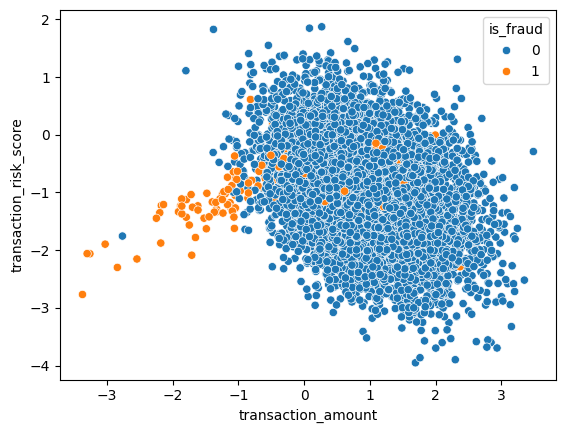

In [11]:
sns.scatterplot(x= X["transaction_amount"], y=X["transaction_risk_score"], hue=y)
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=15)

In [14]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [16]:
penalty = ["l1", "l2", "elasticnet"]
c_values = [100, 10, 1, 0.1, 0.01]
solver = ["newton-cg", "lbfgs", "sag", "saga", "newton-cholesky"]
class_weight = [{0:w, 1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

In [17]:
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [18]:
params = dict(penalty=penalty, C=c_values, solver = solver, class_weight = class_weight)

In [19]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [20]:
cv = StratifiedKFold()

In [21]:
grid = GridSearchCV(estimator = model, param_grid = params, scoring = "accuracy", cv=cv)

In [23]:
import warnings
warnings.filterwarnings("ignore")

In [24]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [100, 10, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : th

In [27]:
y_pred = grid.predict(X_test)

In [28]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2500,))

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [30]:
print("score: ", accuracy_score(y_pred, y_test))
print(classification_report(y_pred, y_test))
print("confusion_matrix: \n", confusion_matrix(y_pred, y_test))

score:  0.99
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2481
           1       0.42      0.84      0.56        19

    accuracy                           0.99      2500
   macro avg       0.71      0.92      0.78      2500
weighted avg       0.99      0.99      0.99      2500

confusion_matrix: 
 [[2459   22]
 [   3   16]]


In [31]:
grid.best_params_

{'C': 0.01,
 'class_weight': {0: 10, 1: 50},
 'penalty': 'l2',
 'solver': 'newton-cg'}

In [32]:
#roc, auc

In [39]:
model_prob  = grid.predict_proba(X_test)

In [40]:
model_prob

array([[0.99586436, 0.00413564],
       [0.85287009, 0.14712991],
       [0.952308  , 0.047692  ],
       ...,
       [0.98898975, 0.01101025],
       [0.98454137, 0.01545863],
       [0.99758734, 0.00241266]], shape=(2500, 2))

In [41]:
model_prob = model_prob[:,1] # probabilities for the positive (fraud) class

In [42]:
model_prob

array([0.00413564, 0.14712991, 0.047692  , ..., 0.01101025, 0.01545863,
       0.00241266], shape=(2500,))

In [43]:
from sklearn.metrics import roc_curve, roc_auc_score

In [44]:
model_auc = (y_test, model_prob)

In [45]:
model_auc

(522     0
 5667    0
 4030    0
 3198    0
 2902    0
        ..
 9855    0
 9040    0
 128     0
 3465    0
 4003    0
 Name: is_fraud, Length: 2500, dtype: int64,
 array([0.00413564, 0.14712991, 0.047692  , ..., 0.01101025, 0.01545863,
        0.00241266], shape=(2500,)))

In [47]:
# model false positive rate
# model true positive rate
model_fpr, model_tpr, thresholds = roc_curve(y_test, model_prob)

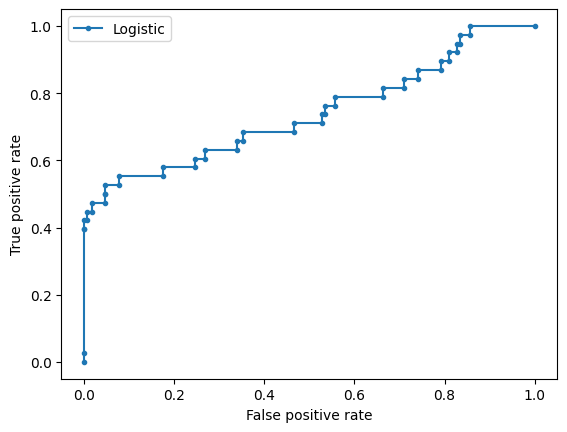

In [49]:
plt.plot(model_fpr, model_tpr, marker = ".", label = "Logistic")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.show()

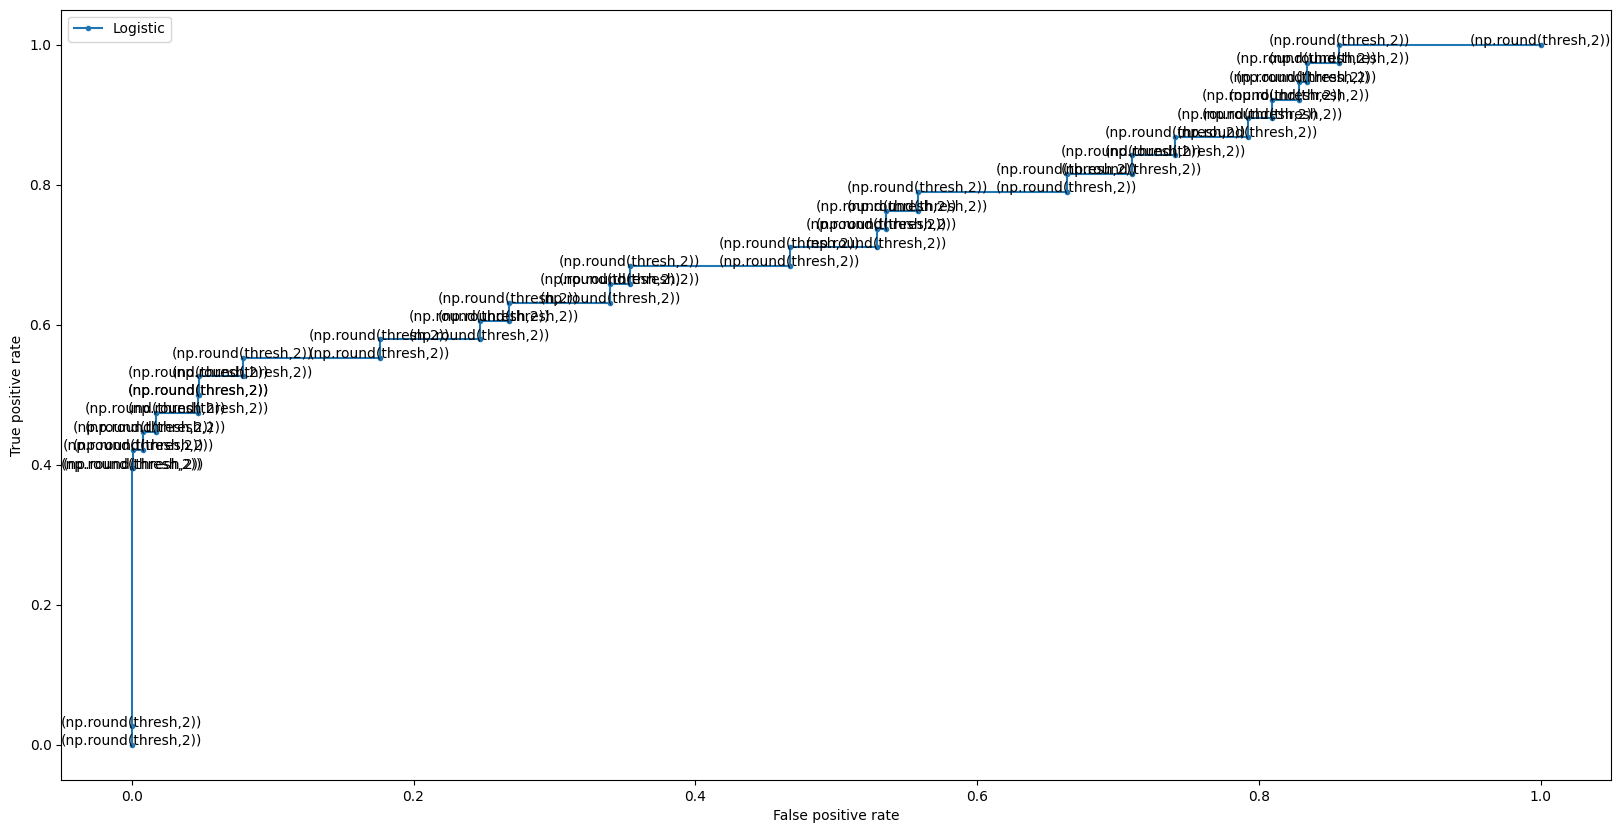

In [53]:
fig, ax = plt.subplots(figsize= (20,10))
ax.plot(model_fpr, model_tpr, marker = ".", label = "Logistic")
for fpr, tpr, thresh in zip(model_fpr, model_tpr, thresholds):
    ax.annotate(f"(np.round(thresh,2))",(fpr,tpr), ha="center")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
plt.legend()
plt.show()

In [57]:
custom_threshold = 0.5
y_pred_custom = ( model_prob >= custom_threshold).astype(int)
y_pred_custom

array([0, 0, 0, ..., 0, 0, 0], shape=(2500,))

In [58]:
print(confusion_matrix(y_pred_custom, y_test))
print(classification_report(y_pred_custom, y_test))

[[2459   22]
 [   3   16]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2481
           1       0.42      0.84      0.56        19

    accuracy                           0.99      2500
   macro avg       0.71      0.92      0.78      2500
weighted avg       0.99      0.99      0.99      2500

